# Assignment 4 - Part II: Diagnosis

Diagnosis is the second step of the PHM loop: after detecting that something is off, identify what kind of state the asset is in. Here, that means unsupervised clustering of the MNIST images from Part I to see whether K-Means can separate the digit classes on its own.

Following the assignment specifications literally: *use K-Means with numpy and matplotlib*, clustering runs on the raw flattened pixel vectors (784-dim), not on autoencoder latents.

## What this notebook covers for the different grades

- **Grade 3:** discern different classes in the Part I dataset. Spec says *the 8 different figures*; treated as a typo since normal MNIST is digits 0 - 8 (9 classes). Using the full train set (digits 0-8) here so the comparison stays honest.
- **Grade 4:** fit K-Means on the flattened MNIST pixels at a fixed `k`, then map clusters to digit labels by majority vote.
- **Grade 5:** sweep `k`, plot inertia vs k (the elbow), and pick the optimal `k` geometrically. Build the 10Ãƒâ€”10 confusion matrix at the chosen `k`.

In [36]:
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

from config import *

In [37]:
print(f"Python    : {sys.version.split()[0]}")
print(f"PyTorch   : {torch.__version__}")
print(f"CUDA      : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device    : {torch.cuda.get_device_name(0)}")
print(f"Conda env : {os.environ.get('CONDA_DEFAULT_ENV', 'unknown')}")

Python    : 3.12.12
PyTorch   : 2.12.0.dev20260408+cu128
CUDA      : True
Device    : NVIDIA GeForce RTX 5050 Laptop GPU
Conda env : py-gpu-sandbox


In [38]:
MNIST_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(SEED)

print(f"k range for elbow : {KMEANS_K_RANGE[0]}..{KMEANS_K_RANGE[-1]}")
print(f"elbow sample size : {KMEANS_SAMPLE_SIZE}")
print(f"n_init            : {KMEANS_N_INIT}")

k range for elbow : 2..15
elbow sample size : 10000
n_init            : auto


## Grade 3 - load MNIST and flatten

Same dataset as Part I, same normalisation. K-Means works on flat numpy arrays, so each `(1, 28, 28)` image becomes a 784-dim vector.

In [39]:
transform=transforms.Compose([transforms.ToTensor(),transforms.Normalize(MNIST_MEAN,MNIST_STD)])
mnist_train=datasets.MNIST(root=str(MNIST_DIR),train=True,download=True,transform=transform)
mask=torch.isin(mnist_train.targets,torch.tensor(MNIST_NORMAL_DIGITS))
imgs=mnist_train.data[mask].float()/255.0
imgs=(imgs-MNIST_MEAN[0])/MNIST_STD[0]
X_all=imgs.view(imgs.size(0),-1).numpy()
y_all=mnist_train.targets[mask].numpy()
print(f'X_all {X_all.shape}, y_all {y_all.shape}, classes {np.unique(y_all)}')


X_all (54051, 784), y_all (54051,), classes [0 1 2 3 4 5 6 7 8]


In [40]:
# Subsample for the elbow sweep.
# Raw 784-dim K-Means over 60k points x many values of k is painful, and the elbow shape is robust to subsampling.
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_all), size=min(KMEANS_SAMPLE_SIZE, len(X_all)), replace=False)
X_sample = X_all[sample_idx]
print(f"sample for elbow: {X_sample.shape}")

sample for elbow: (10000, 784)


## Grade 5 - elbow analysis (run first so the chosen `k` drives the rest)

Inertia is the within-cluster sum of squared distances. It always drops as `k` grows, so we look for the elbow - the point past which the drop becomes marginal.

In [41]:
k_values, inertia_values = [], []

for k in tqdm(KMEANS_K_RANGE, desc="elbow sweep", unit="k"):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=KMEANS_N_INIT)
    km.fit(X_sample)
    k_values.append(int(k))
    inertia_values.append(float(km.inertia_))

elbow sweep:   0%|          | 0/14 [00:00<?, ?k/s]

In [42]:
# Elbow = farthest point from the chord between the first and last (k, inertia).
pts = np.column_stack([np.asarray(k_values, dtype=float),
                       np.asarray(inertia_values, dtype=float)])
start, end = pts[0], pts[-1]
line = end - start
line_norm = line / np.linalg.norm(line)
vecs = pts - start
proj = vecs @ line_norm
dists = np.linalg.norm(vecs - np.outer(proj, line_norm), axis=1)
optimal_k = int(k_values[int(np.argmax(dists))])
print(f"optimal k (elbow): {optimal_k}")

optimal k (elbow): 7


## Grade 4 - fit K-Means at the chosen `k` on the full dataset

In [43]:
kmeans = KMeans(n_clusters=optimal_k, random_state=SEED, n_init=KMEANS_N_INIT)
kmeans.fit(X_all)
cluster_ids = kmeans.predict(X_all)
print(f"fitted K-Means with k={optimal_k} on {len(X_all)} samples")

fitted K-Means with k=7 on 54051 samples


In [44]:
# Map each cluster to a digit by majority vote, so the confusion matrix is
# interpretable in digit space rather than arbitrary cluster IDs.
cluster_to_digit = {}
for c in range(optimal_k):
    members = y_all[cluster_ids == c]
    if len(members) == 0:
        continue
    cluster_to_digit[c] = int(np.bincount(members).argmax())

y_pred = np.array([cluster_to_digit[c] for c in cluster_ids])
accuracy = float((y_pred == y_all).mean())
print(f"majority-vote accuracy at k={optimal_k}: {accuracy:.4f}")
print(f"cluster -> digit map: {cluster_to_digit}")

majority-vote accuracy at k=7: 0.5360
cluster -> digit map: {0: 7, 1: 1, 2: 6, 3: 3, 4: 1, 5: 0, 6: 8}


## What I can extrapolate from this

Raw-pixel K-Means is a hard baseline for MNIST: digits with similar pen strokes (3/8, 7/1, 5/6) often share clusters because Euclidean distance in pixel space measures shape overlap more than digit identity. The elbow tends to land near the true class count (9), but majority-vote accuracy stays modest because some digits split across multiple clusters while others merge.


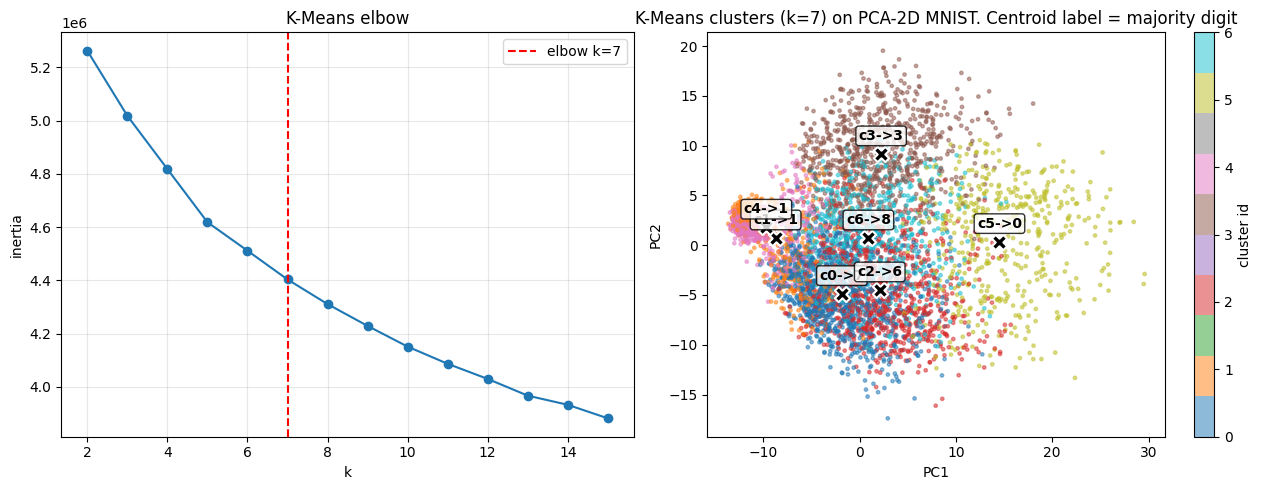

In [45]:
fig,axes=plt.subplots(1,2,figsize=(13,5))

ax=axes[0]
ax.plot(k_values,inertia_values,marker='o')
ax.axvline(optimal_k,color='red',linestyle='--',label=f'elbow k={optimal_k}')

ax.set_xlabel('k')
ax.set_ylabel('inertia')
ax.set_title('K-Means elbow')
ax.legend()
ax.grid(alpha=0.3)

idx=rng.choice(len(X_all),5000,replace=False)
pca=PCA(n_components=2,random_state=SEED).fit(X_all[idx])
X2=pca.transform(X_all[idx])
sc=axes[1].scatter(X2[:,0],X2[:,1],c=cluster_ids[idx],cmap='tab10',s=6,alpha=0.5)

centers2=pca.transform(kmeans.cluster_centers_)

for c in range(optimal_k):
    d=cluster_to_digit.get(c,'?')
    axes[1].scatter(centers2[c,0],centers2[c,1],c='black',s=120,marker='X',edgecolors='white',linewidths=1.5)
    axes[1].annotate(f'c{c}->{d}',(centers2[c,0],centers2[c,1]),fontsize=10,fontweight='bold',
                    ha='center',va='bottom',xytext=(0,8),textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.2',facecolor='white',alpha=0.8))

axes[1].set_title(f'K-Means clusters (k={optimal_k}) on PCA-2D MNIST. Centroid label = majority digit')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.colorbar(sc,ax=axes[1],label='cluster id')
plt.tight_layout()
plt.show()
